<a href="https://colab.research.google.com/github/gamzedrn/Softito-Egitim-Calismalari/blob/main/Scooby_Doo_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kütüphaneleri Yükle

In [6]:
# 1. Kütüphaneleri yükle
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16

from google.colab import drive

print("Kütüphaneler yüklendi!")
print("TensorFlow version:", tf.__version__)

Kütüphaneler yüklendi!
TensorFlow version: 2.20.0


## Drive'ı Bağla

In [8]:
# 2. Google Drive'ı bağla
drive.mount('/content/drive')

# Veri seti yolu
dataset_path = '/content/drive/MyDrive/dataset'

# Klasörleri kontrol et
print("Dataset içindeki klasörler:", os.listdir(dataset_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset içindeki klasörler: ['Scooby', 'Daphne', 'Velma', 'Shaggy', 'Fred']


## Veri Seti Bilgilerini Görüntüle

In [9]:
# 3. Veri seti istatistikleri
class_names = ['Daphne', 'Fred', 'Scooby', 'Shaggy', 'Velma']
class_names_tr = ['Daphne', 'Fred', 'Scooby', 'Shaggy', 'Velma']

print("="*50)
print("VERİ SETİ BİLGİLERİ")
print("="*50)

for class_name in class_names:
    folder_path = os.path.join(dataset_path, class_name)
    if os.path.exists(folder_path):
        num_images = len(os.listdir(folder_path))
        print(f"{class_name:10s}: {num_images:3d} resim")
    else:
        print(f"{class_name:10s}: KLASÖR YOK!")

print("="*50)

VERİ SETİ BİLGİLERİ
Daphne    :  50 resim
Fred      :  50 resim
Scooby    :  40 resim
Shaggy    :  51 resim
Velma     :  30 resim


## Örnek Resimleri Görselleştir

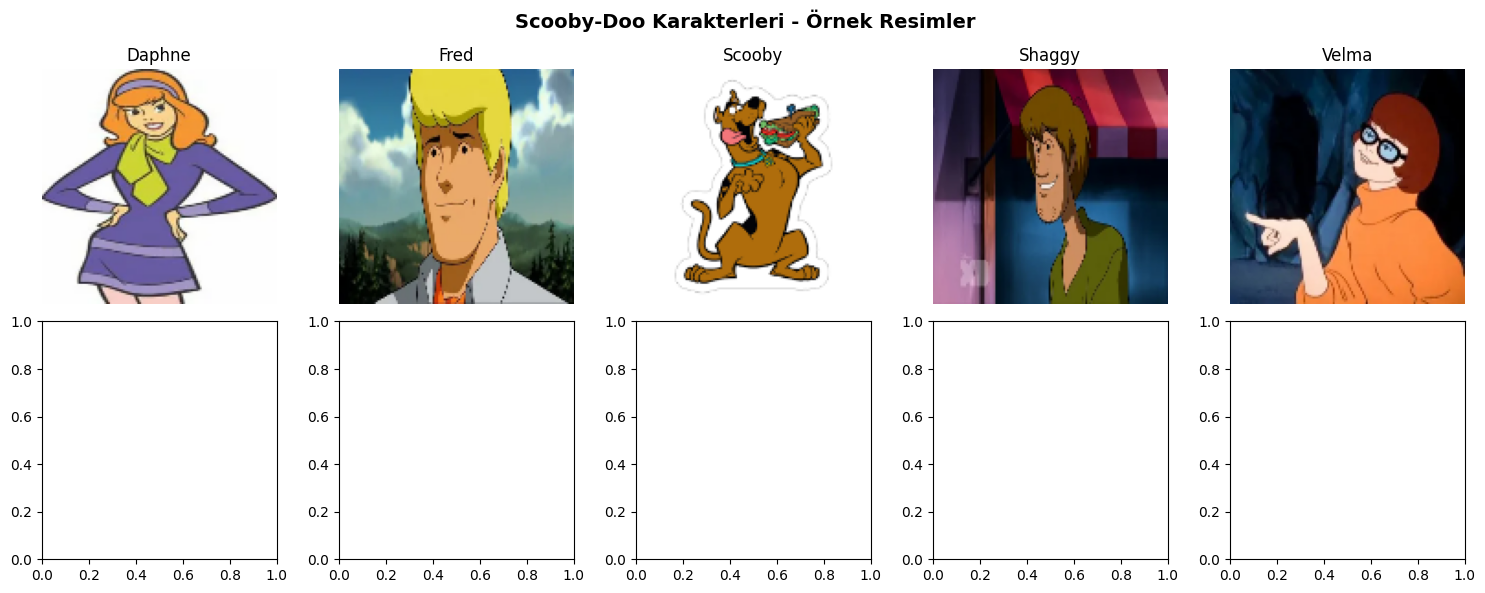

In [10]:
# 4. Her sınıftan örnek resimler göster
import cv2

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Scooby-Doo Karakterleri - Örnek Resimler', fontsize=14, fontweight='bold')

for i, class_name in enumerate(class_names):
    folder_path = os.path.join(dataset_path, class_name)
    if os.listdir(folder_path):
        # İlk resmi al
        img_file = os.listdir(folder_path)[0]
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (128, 128))

        row = i // 5
        col = i % 5
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name, fontsize=12)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Veri Artırma (Augmentation) ve Veri Yükleme

In [11]:
# 5. Data Augmentation ayarları
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 30

train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalizasyon
    rotation_range=30,           # Rastgele döndürme
    width_shift_range=0.2,       # Yatay kaydırma
    height_shift_range=0.2,      # Dikey kaydırma
    shear_range=0.2,             # Eğme
    zoom_range=0.2,              # Yakınlaştırma
    horizontal_flip=True,        # Yatay çevirme
    brightness_range=[0.8, 1.2], # Parlaklık
    validation_split=0.2         # %20 doğrulama
)

# Validation için augmentation YOK (sadece normalizasyon)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Eğitim generator
train_gen = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Doğrulama generator
val_gen = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Test seti (ayrı bir test klasörün yoksa doğrulamayı test olarak kullan)
test_gen = val_gen

print("\n" + "="*50)
print(f"Eğitim seti: {train_gen.samples} resim")
print(f"Doğrulama seti: {val_gen.samples} resim")
print(f"Sınıflar: {train_gen.class_indices}")
print("="*50)

Found 177 images belonging to 5 classes.
Found 44 images belonging to 5 classes.

Eğitim seti: 177 resim
Doğrulama seti: 44 resim
Sınıflar: {'Daphne': 0, 'Fred': 1, 'Scooby': 2, 'Shaggy': 3, 'Velma': 4}


## CNN Modeli Oluştur (Optimize Edilmiş)

In [12]:
# 6. CNN Modeli (Az parametre - Overfit önlemek için)
def build_cnn():
    model = models.Sequential([
        # Girdi katmanı
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Blok 1
        layers.Conv2D(16, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(16, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Blok 2
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Blok 3
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Karar katmanları
        layers.GlobalAveragePooling2D(),  # Flatten yerine GAP (çok daha az parametre)
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(5, activation='softmax')  # 5 sınıf
    ])
    return model

cnn_model = build_cnn()
cnn_model.summary()

# Parametre sayısını yorumla
total_params = cnn_model.count_params()
print(f"\nToplam Parametre: {total_params:,}")
print(f"Bu, önceki modelden {(12941381/total_params):.1f} kat daha az!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 53,205 (207.83 KB)

 Trainable params: 52,629 (205.58 KB)

 Non-trainable params: 576 (2.25 KB)


Toplam Parametre: 53,205
Bu, önceki modelden 243.2 kat daha az!


## Callback'leri Tanımla

In [13]:
# 7. Callback'ler
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='/content/drive/MyDrive/best_scooby_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print("Callback'ler hazır:")
print("  ✓ EarlyStopping (patience=10)")
print("  ✓ ReduceLROnPlateau (factor=0.5, patience=5)")
print("  ✓ ModelCheckpoint (best model kaydedilecek)")

Callback'ler hazır:
  ✓ EarlyStopping (patience=10)
  ✓ ReduceLROnPlateau (factor=0.5, patience=5)
  ✓ ModelCheckpoint (best model kaydedilecek)


## Modeli Derle ve Eğit

In [14]:
# 8. Modeli derle
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("="*60)
print("  CNN Modeli Eğitimi Başlıyor")
print("="*60)

# Eğit
history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

print("\n✅ Eğitim tamamlandı!")

  CNN Modeli Eğitimi Başlıyor
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2429 - loss: 2.2990 - val_accuracy: 0.2273 - val_loss: 1.6059 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.2316 - loss: 2.1784 - val_accuracy: 0.2273 - val_loss: 1.5989 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.2429 - loss: 1.9988 - val_accuracy: 0.2273 - val_loss: 1.5979 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 990ms/step - accuracy: 0.2994 - loss: 2.0234 - val_accuracy: 0.2273 - val_loss: 1.6055 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3333 - loss: 1.8043 - val_accuracy: 0.2273 - val_loss: 1.6115 - learning_rate: 0.0010
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 983ms/step - accuracy: 0.3616 - loss: 1.6942 - val_accuracy: 0.2273 - val_loss: 1.6199 - learning_rate: 0.0010
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 805ms/step - accuracy:

## Eğitim Sonuçlarını Görselleştir

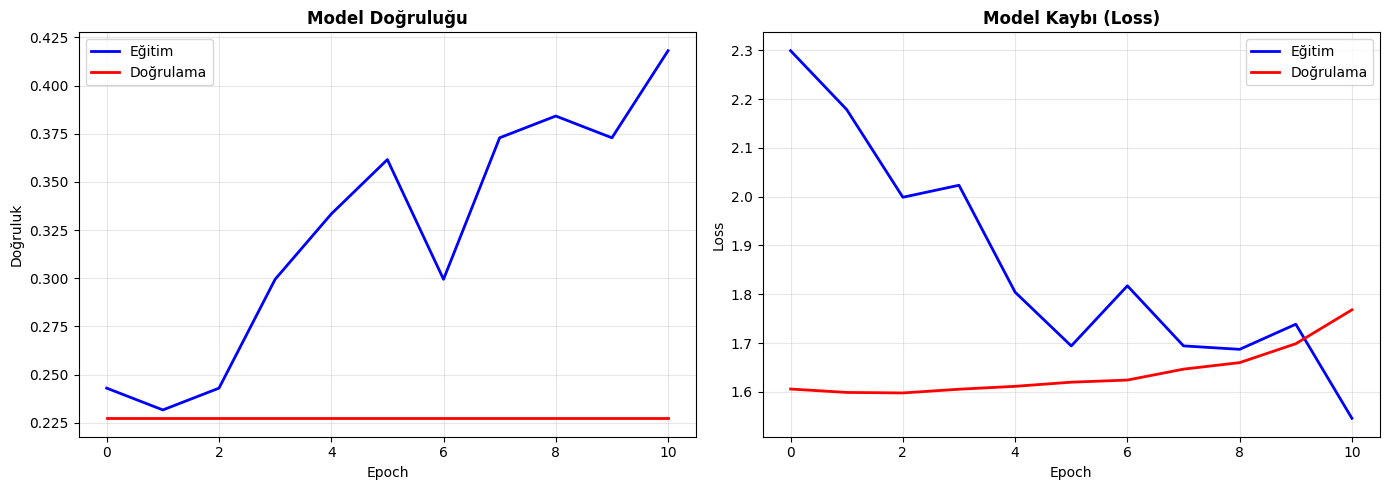


📊 En İyi Sonuçlar:
   En iyi doğrulama doğruluğu: 0.2273 (22.7%)
   En iyi doğrulama kaybı: 1.5979


In [15]:
# 9. Eğitim grafikleri
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Doğruluk grafiği
axes[0].plot(history.history['accuracy'], 'b-', label='Eğitim', linewidth=2)
axes[0].plot(history.history['val_accuracy'], 'r-', label='Doğrulama', linewidth=2)
axes[0].set_title('Model Doğruluğu', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Doğruluk')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss grafiği
axes[1].plot(history.history['loss'], 'b-', label='Eğitim', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-', label='Doğrulama', linewidth=2)
axes[1].set_title('Model Kaybı (Loss)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# En iyi değerleri göster
best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
print(f"\n📊 En İyi Sonuçlar:")
print(f"   En iyi doğrulama doğruluğu: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)")
print(f"   En iyi doğrulama kaybı: {best_val_loss:.4f}")

## Test Setinde Değerlendirme

  TEST SETİ DEĞERLENDİRMESİ
✅ Test Doğruluğu: 0.2273 (22.7%)
✅ Test Kaybı: 1.6059

📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Daphne     0.0000    0.0000    0.0000        10
        Fred     0.0000    0.0000    0.0000        10
      Scooby     0.0000    0.0000    0.0000         8
      Shaggy     0.2273    1.0000    0.3704        10
       Velma     0.0000    0.0000    0.0000         6

    accuracy                         0.2273        44
   macro avg     0.0455    0.2000    0.0741        44
weighted avg     0.0517    0.2273    0.0842        44



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


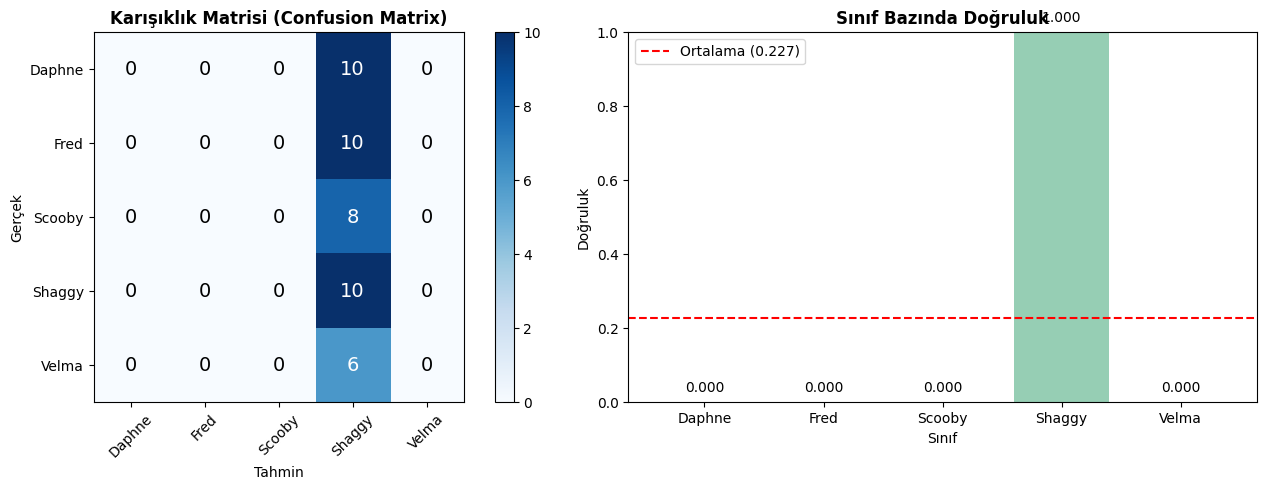


🔍 Hata Analizi:
   Toplam test resmi: 44
   Doğru tahmin: 10
   Yanlış tahmin: 34
   Hata oranı: 77.27%


In [17]:
# 10. Test setinde değerlendirme
print("="*60)
print("  TEST SETİ DEĞERLENDİRMESİ")
print("="*60)

# Test setinde tahmin yap
test_loss, test_acc = cnn_model.evaluate(test_gen, verbose=0)
print(f"✅ Test Doğruluğu: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"✅ Test Kaybı: {test_loss:.4f}")

# Detaylı tahminler
y_pred_prob = cnn_model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

# Sınıflandırma raporu
print("\n📋 Sınıflandırma Raporu:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Karışıklık Matrisi (Confusion Matrix)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tahmin', fontsize=10)
axes[0].set_ylabel('Gerçek', fontsize=10)
plt.colorbar(im, ax=axes[0])

for i in range(5):
    for j in range(5):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14, color=color)

axes[0].set_xticks(range(5))
axes[0].set_xticklabels(class_names, rotation=45)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels(class_names)

# 2. Doğruluk grafiği (her sınıf için)
class_accuracies = []
for i in range(5):
    mask = (y_true == i)
    if np.sum(mask) > 0:
        class_acc = np.mean(y_pred[mask] == i)
        class_accuracies.append(class_acc)
    else:
        class_accuracies.append(0)

bars = axes[1].bar(class_names, class_accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
axes[1].set_title('Sınıf Bazında Doğruluk', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sınıf')
axes[1].set_ylabel('Doğruluk')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=test_acc, color='red', linestyle='--', label=f'Ortalama ({test_acc:.3f})')
axes[1].legend()

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Hata analizi
print("\n🔍 Hata Analizi:")
print(f"   Toplam test resmi: {len(y_true)}")
print(f"   Doğru tahmin: {np.sum(y_pred == y_true)}")
print(f"   Yanlış tahmin: {np.sum(y_pred != y_true)}")
print(f"   Hata oranı: {np.sum(y_pred != y_true)/len(y_true):.2%}")

## Transfer Learning (VGG16) ile Dene

In [18]:
# 11. Transfer Learning Modeli (VGG16)
print("="*60)
print("  TRANSFER LEARNING - VGG16 MODELİ")
print("="*60)

from tensorflow.keras.applications import VGG16

def build_transfer_model():
    # Base model (VGG16)
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False  # Tüm katmanları dondur

    # Özel sınıflandırıcı baş
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(5, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base_model

tl_model, base_model = build_transfer_model()

# Model özeti
tl_model.summary()

# Parametre sayısı
print(f"\nToplam parametre: {tl_model.count_params():,}")
print(f"Eğitilebilir parametre: {sum([tf.size(w).numpy() for w in tl_model.trainable_weights]):,}")

# Derle
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Eğit
print("\n🚀 Transfer Learning eğitiliyor...")
tl_history = tl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_list,
    verbose=1
)

# Değerlendir
tl_test_loss, tl_test_acc = tl_model.evaluate(test_gen, verbose=0)
print(f"\n✅ Transfer Learning Test Doğruluğu: {tl_test_acc:.4f} ({tl_test_acc*100:.1f}%)")

  TRANSFER LEARNING - VGG16 MODELİ
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,581 (56.76 MB)

 Trainable params: 165,381 (646.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)


Toplam parametre: 14,880,581
Eğitilebilir parametre: 165,381

🚀 Transfer Learning eğitiliyor...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.1921 - loss: 2.3417 - val_accuracy: 0.2273 - val_loss: 1.5842 - learning_rate: 0.0010
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.3672 - loss: 1.6858 - val_accuracy: 0.3182 - val_loss: 1.4974 - learning_rate: 0.0010
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 0.4915 - loss: 1.3909 - val_accuracy: 0.2955 - val_loss: 1.4584 - learning_rate: 0.0010
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.4972 - loss: 1.2435 - val_accuracy: 0.3636 - val_loss: 1.4158 - learning_rate: 0.0010
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.5593 - loss: 1.0871 - val_accuracy: 0.4773 - val_loss: 1.3467 - learning_rate: 0.0010
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 0.6610 - loss: 0.9342 - val_accuracy: 0.5000 - val_loss: 1.2959 - learning_rate: 0.0010
Epo

## İki Modeli Karşılaştır

  MODEL KARŞILAŞTIRMASI


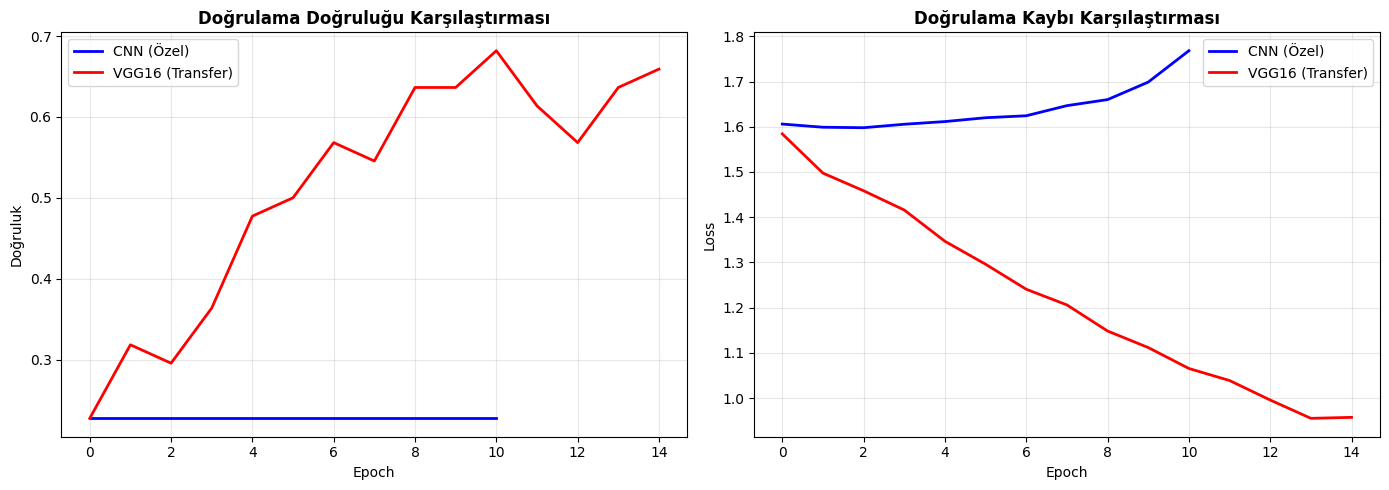


 SONUÇ TABLOSU:
--------------------------------------------------
Model                     Test Doğruluğu  Parametre Sayısı
--------------------------------------------------
CNN (Özel)                0.2273 (22.7%)       53,205
VGG16 (Transfer)          0.6818 (68.2%)       14,880,581
--------------------------------------------------

 Transfer Learning modeli 45.45% daha iyi performans gösterdi!


In [19]:
# 12. CNN vs Transfer Learning Karşılaştırması
print("="*60)
print("  MODEL KARŞILAŞTIRMASI")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Doğruluk karşılaştırması
axes[0].plot(history.history['val_accuracy'], 'b-', label='CNN (Özel)', linewidth=2)
axes[0].plot(tl_history.history['val_accuracy'], 'r-', label='VGG16 (Transfer)', linewidth=2)
axes[0].set_title('Doğrulama Doğruluğu Karşılaştırması', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Doğruluk')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss karşılaştırması
axes[1].plot(history.history['val_loss'], 'b-', label='CNN (Özel)', linewidth=2)
axes[1].plot(tl_history.history['val_loss'], 'r-', label='VGG16 (Transfer)', linewidth=2)
axes[1].set_title('Doğrulama Kaybı Karşılaştırması', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sonuç tablosu
print("\n SONUÇ TABLOSU:")
print("-" * 50)
print(f"{'Model':<25} {'Test Doğruluğu':<15} {'Parametre Sayısı':<15}")
print("-" * 50)
print(f"{'CNN (Özel)':<25} {test_acc:.4f} ({test_acc*100:.1f}%){'':<6} {total_params:,}")
print(f"{'VGG16 (Transfer)':<25} {tl_test_acc:.4f} ({tl_test_acc*100:.1f}%){'':<6} {tl_model.count_params():,}")
print("-" * 50)

# Hangisi daha iyi?
if test_acc > tl_test_acc:
    print(f"\n CNN modeli {test_acc-tl_test_acc:.2%} daha iyi performans gösterdi!")
else:
    print(f"\n Transfer Learning modeli {tl_test_acc-test_acc:.2%} daha iyi performans gösterdi!")

## En İyi Modeli Kaydet

In [20]:
# 13. En iyi modeli seç ve kaydet
if test_acc >= tl_test_acc:
    best_model = cnn_model
    best_model_name = "CNN_Özel"
    best_acc = test_acc
else:
    best_model = tl_model
    best_model_name = "VGG16_Transfer"
    best_acc = tl_test_acc

# Drive'a kaydet
save_path = f'/content/drive/MyDrive/scooby_best_{best_model_name}.keras'
best_model.save(save_path)
print(f" En iyi model kaydedildi: {save_path}")
print(f"   Model: {best_model_name}")
print(f"   Doğruluk: {best_acc:.4f} ({best_acc*100:.1f}%)")

# Modeli yükleme kodu (ileri kullanım için)
print(f"\n İleride yüklemek için:")
print(f"   model = tf.keras.models.load_model('{save_path}')")

 En iyi model kaydedildi: /content/drive/MyDrive/scooby_best_VGG16_Transfer.keras
   Model: VGG16_Transfer
   Doğruluk: 0.6818 (68.2%)

 İleride yüklemek için:
   model = tf.keras.models.load_model('/content/drive/MyDrive/scooby_best_VGG16_Transfer.keras')


## Proje Özet Raporu

In [21]:
# 14. Tam özet rapor
print("\n" + "="*70)
print("  SCOOBY-DOO KARAKTER SINIFLANDIRMA - PROJE RAPORU")
print("="*70)

print(f"\n VERİ SETİ:")
print(f"   ├─ Sınıf sayısı: {len(class_names)}")
print(f"   ├─ Sınıflar: {', '.join(class_names)}")
print(f"   ├─ Eğitim resmi: {train_gen.samples}")
print(f"   └─ Doğrulama resmi: {val_gen.samples}")

print(f"\n MODELLER:")
print(f"   ├─ CNN (Özel): {total_params:,} parametre")
print(f"   └─ VGG16 (Transfer): {tl_model.count_params():,} parametre")

print(f"\n PERFORMANS:")
print(f"   ├─ CNN (Özel) - Test Doğruluğu: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"   └─ VGG16 (Transfer) - Test Doğruluğu: {tl_test_acc:.4f} ({tl_test_acc*100:.1f}%)")

print(f"\n EN İYİ MODEL:")
print(f"   ├─ Model: {best_model_name}")
print(f"   ├─ Test Doğruluğu: {best_acc:.4f} ({best_acc*100:.1f}%)")
print(f"   └─ Kayıt yeri: {save_path}")

print(f"\n HATA ANALİZİ (En iyi model için):")
if best_model_name == "CNN_Özel":
    y_pred_best = y_pred
else:
    y_pred_prob_best = tl_model.predict(test_gen, verbose=0)
    y_pred_best = np.argmax(y_pred_prob_best, axis=1)
y_true_best = test_gen.classes
wrong_pred_idx = np.where(y_pred_best != y_true_best)[0]
print(f"   ├─ Toplam hata: {len(wrong_pred_idx)} / {len(y_true_best)} resim")
print(f"   └─ Hata oranı: {len(wrong_pred_idx)/len(y_true_best):.2%}")

print("\n" + "="*70)
print("  PROJE BAŞARIYLA TAMAMLANDI! ")
print("="*70)

# Başarı notu
if best_acc >= 0.8:
    print("\n MÜKEMMEL! Model çok başarılı!")
elif best_acc >= 0.6:
    print("\n İYİ! Model kabul edilebilir seviyede.")
elif best_acc >= 0.4:
    print("\n ORTA! Daha fazla veri veya düzenleme gerekli.")
else:
    print("\n KÖTÜ! Veri setini veya modeli gözden geçirmelisin.")


  SCOOBY-DOO KARAKTER SINIFLANDIRMA - PROJE RAPORU

 VERİ SETİ:
   ├─ Sınıf sayısı: 5
   ├─ Sınıflar: Daphne, Fred, Scooby, Shaggy, Velma
   ├─ Eğitim resmi: 177
   └─ Doğrulama resmi: 44

 MODELLER:
   ├─ CNN (Özel): 53,205 parametre
   └─ VGG16 (Transfer): 14,880,581 parametre

 PERFORMANS:
   ├─ CNN (Özel) - Test Doğruluğu: 0.2273 (22.7%)
   └─ VGG16 (Transfer) - Test Doğruluğu: 0.6818 (68.2%)

 EN İYİ MODEL:
   ├─ Model: VGG16_Transfer
   ├─ Test Doğruluğu: 0.6818 (68.2%)
   └─ Kayıt yeri: /content/drive/MyDrive/scooby_best_VGG16_Transfer.keras

 HATA ANALİZİ (En iyi model için):
   ├─ Toplam hata: 14 / 44 resim
   └─ Hata oranı: 31.82%

  PROJE BAŞARIYLA TAMAMLANDI! 

 İYİ! Model kabul edilebilir seviyede.
